# Homework 02: Multi-Class Classification with Neural Networks

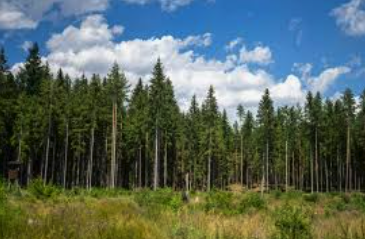

In this assignment, you’ll extend your Keras classification toolkit by training a neural network on a **balanced subset of the Forest Cover (Covertype) dataset**. We’ll begin with a simple baseline network, then study how performance changes as we vary **batch size**, **learning rate**, and apply a **cosine-decay schedule**.

For each configuration, you will consider a range of hyperparameter values, plot training/validation **loss** and **accuracy** over epochs, and determine which choice gave the best performance. 

Finally, you will consider all that you have learned and build your best model and run it on the test set. 


There are 9 graded questions, each worth 9 points, and you get 4 points for free if you complete the whole homework. 


In [1]:
# Useful imports

import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.datasets import fetch_covtype

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense,Input
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.optimizers.schedules import CosineDecay

random_seed = 42

tf.random.set_seed(random_seed)

os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2'  # Suppresses INFO and WARNING messages

2026-02-03 16:40:25.558031: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
2026-02-03 16:40:27.097937: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-02-03 16:40:30.854328: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.


$$k\cdot\sigma$$

In [2]:
# Utility function: Plotting Training Loss (categorical x-entropy) and Accuracy

# Takes the history object returned by fit

def plot_history(history):
    n_epochs = len(history.history['accuracy'])
    epochs = range(1, n_epochs + 1)

    plt.figure(figsize=(7, 8))

    plt.subplot(2, 1, 1)
    plt.plot(epochs, history.history['loss'], label='Training Loss (Xent)', color='tab:red')
    plt.ylabel('Loss')
    plt.title('Training Loss')
    plt.grid(True)
    plt.legend()

    plt.subplot(2, 1, 2)
    plt.plot(epochs, history.history['accuracy'], label='Training Accuracy', color='tab:blue')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.ylim(0, 1.05)
    plt.title('Training Accuracy')
    plt.grid(True)
    plt.legend(loc='upper left')

    plt.tight_layout()
    plt.show()

    final_loss = history.history['loss'][-1]
    final_acc = history.history['accuracy'][-1]
    print(f'Final Training Loss:     {final_loss:.4f}')
    print(f'Final Training Accuracy: {final_acc:.4f}')

## Load the dataset

The dataset is described in detail in the Appendix. For the purposes of this homework, we are selecting a random sample with 2747 samples in each class (to preserve balance), because the original dataset is both very large and very imbalanced, with the smallest class having 2747 samples. 

In [3]:

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from collections import Counter
import numpy as np

# Load
X, y = fetch_covtype(return_X_y=True)   # y in {1..7}
classes, counts = np.unique(y, return_counts=True)
min_count = counts.min()                # size of rarest class (~2.7k)

# Build perfectly balanced subset (no replacement, no duplicates)
rng = np.random.default_rng(42)
idx_list = []
for c in classes:
    c_idx = np.where(y == c)[0]
    chosen = rng.choice(c_idx, size=min_count, replace=False)
    idx_list.append(chosen)

idx_bal = np.concatenate(idx_list)
rng.shuffle(idx_bal)

X_sub = X[idx_bal]
y_sub = y[idx_bal] - 1                  # relabel to 0..6 for Keras
print("Subset shape:", X_sub.shape, "Class counts:", Counter(y_sub))


Subset shape: (19229, 54) Class counts: Counter({np.int32(3): 2747, np.int32(2): 2747, np.int32(6): 2747, np.int32(5): 2747, np.int32(4): 2747, np.int32(1): 2747, np.int32(0): 2747})


## Problem One: Prepare the dataset and build a baseline model

### Part A: Stratified train/test split and standardization

As in Homework 1, follow these three steps:

1. **Stratified split:**
   Use `train_test_split` with `stratify=y_sub` to preserve class proportions in both training and test sets. Be sure to set `random_state=random_seed` and `test_size=0.2`.

2. **Standardize features:**
   Scale the input features so they have mean 0 and variance 1.



In [4]:
# Your code here
# Problem 1 — Part A: Stratified train/test split + standardization
# In this step I’m creating a **stratified** train/test split so each class keeps the same proportions in both sets. 
# Then I standardize the features using `StandardScaler`, making sure I **fit only on the training set** (to avoid data leakage) and 
# Then transform both train and test. This matters because neural nets train more smoothly when inputs are on a comparable scale, and it keeps my evaluation honest.

# Part A: Stratified train/test split and standardization

# --- 1) Stratified split (preserve class proportions) ---
X_train, X_test, y_train, y_test = train_test_split(
    X_sub,
    y_sub,
    test_size=0.2,
    random_state=random_seed,
    stratify=y_sub
)

# Quick sanity checks on shapes + class balance
print("X_train shape:", X_train.shape, "y_train shape:", y_train.shape)
print("X_test  shape:", X_test.shape,  "y_test  shape:", y_test.shape)
print("Train class counts:", Counter(y_train))
print("Test  class counts:", Counter(y_test))

# --- 2) Standardize features (fit scaler ONLY on training data to avoid leakage) ---
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Validation: training data should be ~mean 0, std 1 (per-feature); test will be close-ish
print("\nScaled feature check (training set):")
print("Mean (first 5 features):", np.mean(X_train_scaled, axis=0)[:5])
print("Std  (first 5 features):", np.std(X_train_scaled, axis=0)[:5])

# Extra safety check: make sure labels look like 0..6 and match model expectation
unique_labels = np.unique(y_train)
print("\nUnique labels in y_train:", unique_labels)
assert unique_labels.min() == 0 and unique_labels.max() == 6, "Expected labels to be in {0..6}."


X_train shape: (15383, 54) y_train shape: (15383,)
X_test  shape: (3846, 54) y_test  shape: (3846,)
Train class counts: Counter({np.int32(5): 2198, np.int32(1): 2198, np.int32(0): 2198, np.int32(2): 2198, np.int32(6): 2197, np.int32(3): 2197, np.int32(4): 2197})
Test  class counts: Counter({np.int32(3): 550, np.int32(4): 550, np.int32(6): 550, np.int32(1): 549, np.int32(0): 549, np.int32(5): 549, np.int32(2): 549})

Scaled feature check (training set):
Mean (first 5 features): [-4.39773320e-16 -5.36899340e-17 -4.39960967e-17  8.00099620e-17
  2.54659165e-17]
Std  (first 5 features): [1. 1. 1. 1. 1.]

Unique labels in y_train: [0 1 2 3 4 5 6]


### Part B: Build, compile, train, and evaluate the network

1. **Build the model**

   * Use 2 hidden layers:  input &rarr; 64 &rarr; 32 &rarr; output.
   * Apply the `relu` activation for the hidden layers and `softmax` for the output layer.

2. **Compile the model**

    * Use the following parameters


           optimizer = Adam(learning_rate=0.0001),  
           loss = 'sparse_categorical_crossentropy',  
           metrics = ['accuracy']


4. **Train the model**

   * Run for **20 epochs**.
   * Use a `batch_size` of 32.

5. **Evaluate training**

   * Plot the training loss and accuracy curves using `plot_history`.

6. **Answer the graded questions**



n_features: 54 | n_classes: 7


2026-02-03 16:40:55.354745: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │         3,520 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 7)              │           231 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 5,831 (22.78 KB)

 Trainable params: 5,831 (22.78 KB)

 Non-trainable params: 0 (0.00 B)

None
Epoch 1/20
385/385 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.3017 - loss: 1.8412 - val_accuracy: 0.4472 - val_loss: 1.6072
Epoch 2/20
385/385 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.5063 - loss: 1.4257 - val_accuracy: 0.5473 - val_loss: 1.2752
Epoch 3/20
385/385 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.5742 - loss: 1.1602 - val_accuracy: 0.5905 - val_loss: 1.0808
Epoch 4/20
385/385 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.6086 - loss: 1.0144 - val_accuracy: 0.6149 - val_loss: 0.9781
Epoch 5/20
385/385 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.6342 - loss: 0.9342 - val_accuracy: 0.6321 - val_loss: 0.9183
Epoch 6/20
385/385 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.6489 - loss: 0.8849 - val_accuracy: 0.6454 - val_loss: 0.8796
Epoch 7/20
385/385 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.6575 - loss: 0.8507 - val_accuracy: 0.6549 - val_loss: 0.8513
Epoch 8/20
385/385 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.6689 - loss: 0.8248 - val_accurac

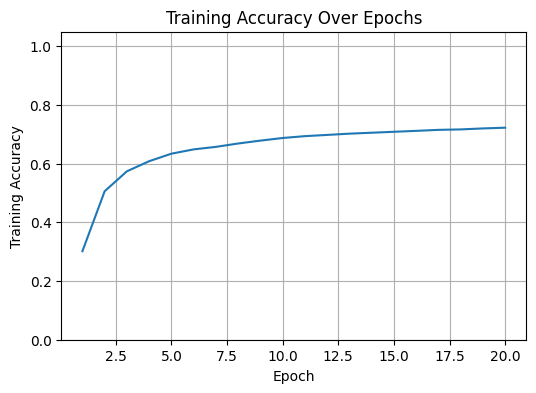

In [5]:
# Your code here
## Problem 1 — Part B: Build, compile, train, and evaluate the baseline network
# In this part I build the baseline neural network exactly as specified (64 → 32 → output), compile it with Adam using the given learning rate, train it for 20 epochs, and 
# then evaluate it on both train and test to sanity-check overfitting. I also add one simple accuracy plot at the end so I can visually confirm the training behavior matches the printed results.

# Problem 1 — Part B: Build, compile, train, evaluate, and add a simple visual

# --- 0) Quick safety checks so I don't get weird errors later ---
# I’m making sure Part A already ran and created the scaled arrays.
required_vars = ["X_train_scaled", "X_test_scaled", "y_train", "y_test"]
missing = [v for v in required_vars if v not in globals()]
assert not missing, f"Missing variables (run Part A first): {missing}"

n_features = X_train_scaled.shape[1]
n_classes = len(np.unique(y_train))
print("n_features:", n_features, "| n_classes:", n_classes)

# --- 1) Build the model (input -> 64 -> 32 -> output) ---
model = Sequential([
    Input(shape=(n_features,)),
    Dense(64, activation="relu"),
    Dense(32, activation="relu"),
    Dense(n_classes, activation="softmax")
])

print(model.summary())

# --- 2) Compile the model (per instructions) ---
model.compile(
    optimizer=Adam(learning_rate=0.0001),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

# --- 3) Train the model (20 epochs, batch size 32) ---
# I’m using a validation split from the training set so I can spot overfitting early.
history = model.fit(
    X_train_scaled,
    y_train,
    epochs=20,
    batch_size=32,
    validation_split=0.2,
    verbose=1
)

# --- 4) Evaluate on train and test (sanity check generalization) ---
train_loss, train_acc = model.evaluate(X_train_scaled, y_train, verbose=0)
test_loss, test_acc = model.evaluate(X_test_scaled, y_test, verbose=0)

print(f"\nFinal Train Accuracy: {train_acc:.4f} | Train Loss: {train_loss:.4f}")
print(f"Final Test  Accuracy: {test_acc:.4f} | Test  Loss: {test_loss:.4f}")

# --- 5) Simple visual: training accuracy over epochs (goes AFTER history exists) ---
epochs = range(1, len(history.history["accuracy"]) + 1)

plt.figure(figsize=(6, 4))
plt.plot(epochs, history.history["accuracy"])
plt.xlabel("Epoch")
plt.ylabel("Training Accuracy")
plt.title("Training Accuracy Over Epochs")
plt.ylim(0, 1.05)
plt.grid(True)
plt.show()

In [6]:
# Set a1a to the final training accuracy at epoch 20
# I’m pulling this directly from the training History object so I’m not copying numbers by hand.
# (This also makes it reproducible if I rerun training.)

a1a = float(history.history["accuracy"][-1])
print(f"Pulled a1a from history (epoch 20 train accuracy): {a1a:.4f}")

Pulled a1a from history (epoch 20 train accuracy): 0.7228


In [7]:
# Graded Answer
# DO NOT change this cell in any way          

print(f'a1a = {a1a:.4f}')  

a1a = 0.7228


## Problem Two: Batch Sizes

Next, we’ll explore how the **batch size** affects training. .

* Start with the code from Problem One.
* Run **four experiments** using a batch size of 4, 8, 16, and 128, and  displaying the results using `plot_history`.

* Answer the graded questions.

**Note:** Consider using a `for` loop!


Training with batch_size = 4
Epoch 1/20


3077/3077 ━━━━━━━━━━━━━━━━━━━━ 6s 2ms/step - accuracy: 0.4983 - loss: 1.3771 - val_accuracy: 0.6055 - val_loss: 1.0123
Epoch 2/20
3077/3077 ━━━━━━━━━━━━━━━━━━━━ 5s 1ms/step - accuracy: 0.6386 - loss: 0.9136 - val_accuracy: 0.6497 - val_loss: 0.8627
Epoch 3/20
3077/3077 ━━━━━━━━━━━━━━━━━━━━ 5s 1ms/step - accuracy: 0.6641 - loss: 0.8220 - val_accuracy: 0.6727 - val_loss: 0.8063
Epoch 4/20
3077/3077 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - accuracy: 0.6816 - loss: 0.7749 - val_accuracy: 0.6831 - val_loss: 0.7703
Epoch 5/20
3077/3077 ━━━━━━━━━━━━━━━━━━━━ 4s 1ms/step - accuracy: 0.6928 - loss: 0.7426 - val_accuracy: 0.6900 - val_loss: 0.7441
Epoch 6/20
3077/3077 ━━━━━━━━━━━━━━━━━━━━ 5s 1ms/step - accuracy: 0.7058 - loss: 0.7180 - val_accuracy: 0.7049 - val_loss: 0.7228
Epoch 7/20
3077/3077 ━━━━━━━━━━━━━━━━━━━━ 5s 1ms/step - accuracy: 0.7145 - loss: 0.6979 - val_accuracy: 0.7130 - val_loss: 0.7046
Epoch 8/20
3077/3077 ━━━━━━━━━━━━━━━━━━━━ 4s 1ms/step - accuracy: 0.7209 - loss: 0.6807 - val_accurac

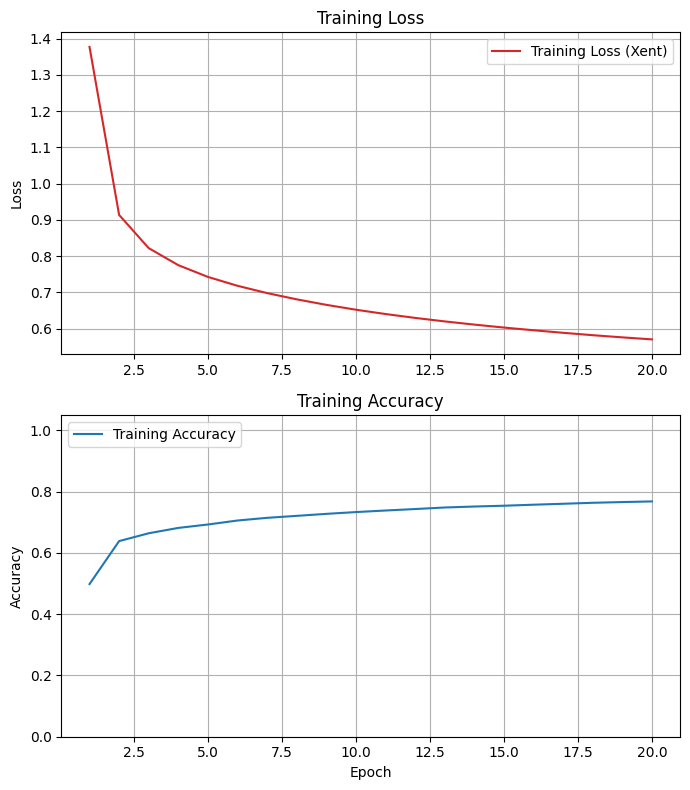

Final Training Loss:     0.5702
Final Training Accuracy: 0.7681
Final training accuracy at epoch 20 (batch_size=4): 0.7681

Training with batch_size = 8
Epoch 1/20
1539/1539 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.4414 - loss: 1.5139 - val_accuracy: 0.5759 - val_loss: 1.1222
Epoch 2/20
1539/1539 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.6122 - loss: 0.9756 - val_accuracy: 0.6201 - val_loss: 0.9124
Epoch 3/20
1539/1539 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.6499 - loss: 0.8579 - val_accuracy: 0.6542 - val_loss: 0.8460
Epoch 4/20
1539/1539 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.6737 - loss: 0.8064 - val_accuracy: 0.6721 - val_loss: 0.8065
Epoch 5/20
1539/1539 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.6877 - loss: 0.7723 - val_accuracy: 0.6848 - val_loss: 0.7770
Epoch 6/20
1539/1539 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.6977 - loss: 0.7464 - val_accuracy: 0.6893 - val_loss: 0.7529
Epoch 7/20
1539/1539 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0

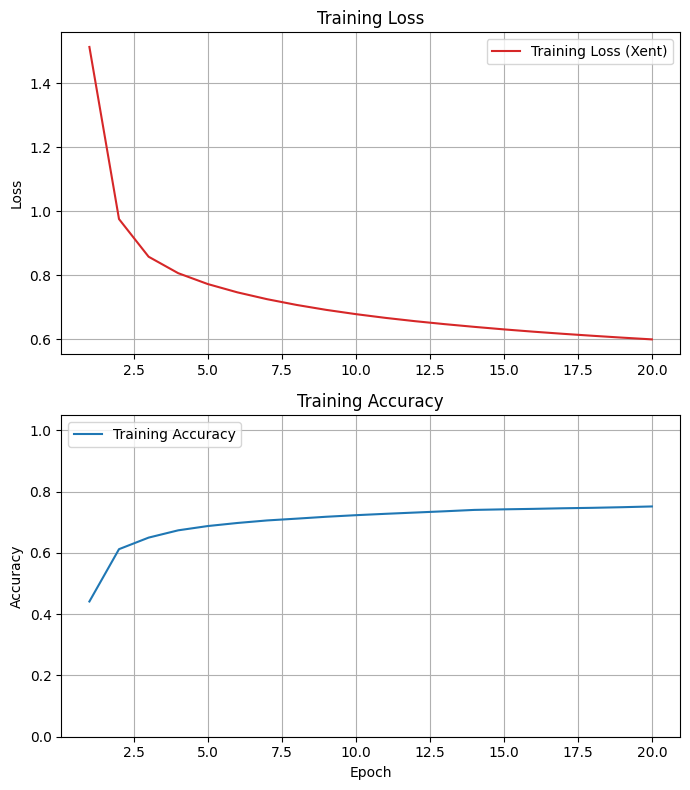

Final Training Loss:     0.5993
Final Training Accuracy: 0.7517
Final training accuracy at epoch 20 (batch_size=8): 0.7517

Training with batch_size = 16
Epoch 1/20
770/770 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.3628 - loss: 1.7040 - val_accuracy: 0.5262 - val_loss: 1.3617
Epoch 2/20
770/770 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.5701 - loss: 1.1691 - val_accuracy: 0.5996 - val_loss: 1.0447
Epoch 3/20
770/770 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.6153 - loss: 0.9688 - val_accuracy: 0.6230 - val_loss: 0.9360
Epoch 4/20
770/770 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.6392 - loss: 0.8897 - val_accuracy: 0.6448 - val_loss: 0.8827
Epoch 5/20
770/770 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.6600 - loss: 0.8445 - val_accuracy: 0.6659 - val_loss: 0.8482
Epoch 6/20
770/770 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.6750 - loss: 0.8130 - val_accuracy: 0.6796 - val_loss: 0.8225
Epoch 7/20
770/770 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.6852 - loss:

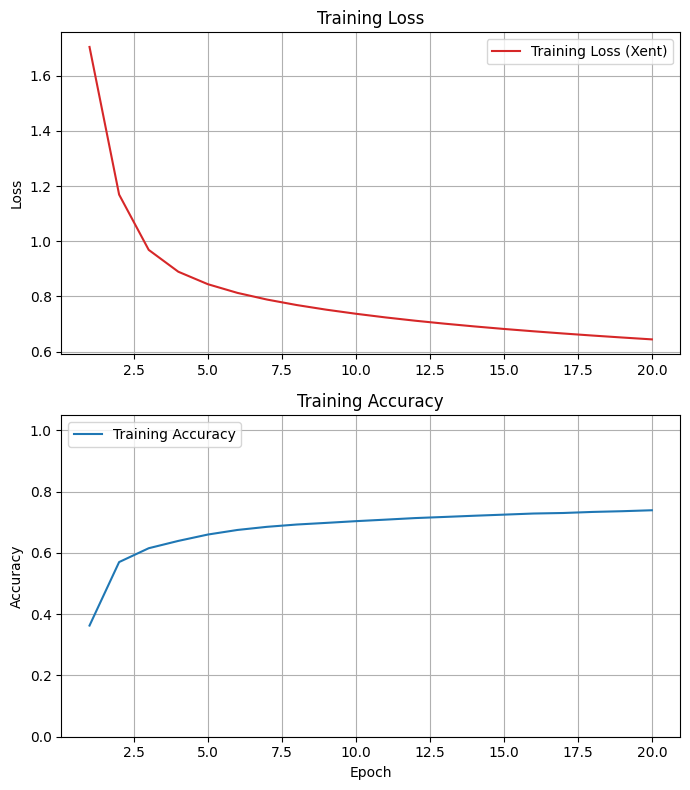

Final Training Loss:     0.6446
Final Training Accuracy: 0.7392
Final training accuracy at epoch 20 (batch_size=16): 0.7392

Training with batch_size = 128
Epoch 1/20
97/97 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.2175 - loss: 1.9475 - val_accuracy: 0.2896 - val_loss: 1.8532
Epoch 2/20
97/97 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.3628 - loss: 1.7694 - val_accuracy: 0.4183 - val_loss: 1.6945
Epoch 3/20
97/97 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.4335 - loss: 1.6108 - val_accuracy: 0.4794 - val_loss: 1.5423
Epoch 4/20
97/97 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.4920 - loss: 1.4619 - val_accuracy: 0.5275 - val_loss: 1.4007
Epoch 5/20
97/97 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.5321 - loss: 1.3289 - val_accuracy: 0.5561 - val_loss: 1.2791
Epoch 6/20
97/97 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.5578 - loss: 1.2173 - val_accuracy: 0.5717 - val_loss: 1.1817
Epoch 7/20
97/97 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.5696 - loss: 1.1294 - va

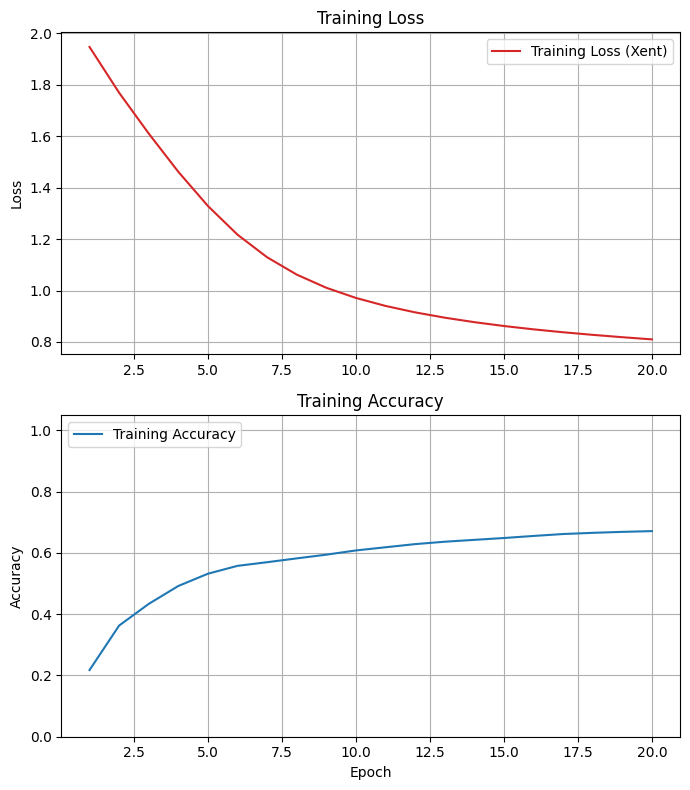

Final Training Loss:     0.8100
Final Training Accuracy: 0.6711
Final training accuracy at epoch 20 (batch_size=128): 0.6711

Summary: Final Training Accuracy at Epoch 20
batch_size=  4 -> acc=0.7681
batch_size=  8 -> acc=0.7517
batch_size= 16 -> acc=0.7392
batch_size=128 -> acc=0.6711

Best batch size (by epoch-20 training accuracy): 4
Best accuracy found (epoch 20): 0.7681


In [8]:
# Your code here
## Problem 2 — Batch Sizes (4, 8, 16, 128)

# In this section I’m keeping the model architecture and optimizer settings the same as the baseline, and I’m only changing the **batch size**. 
# This matters because batch size changes how noisy the gradient updates are: smaller batches usually learn with noisier updates (sometimes better generalization), while larger batches are smoother but can converge differently. 
# I’ll run four experiments, plot each training run using `plot_history`, and then pick the batch size that produces the **best accuracy at epoch 20**.

# Runs 4 experiments with batch sizes [4, 8, 16, 128] using the baseline model setup.

# --- Safety checks (make sure Part A already ran) ---
required_vars = ["X_train_scaled", "y_train"]
missing = [v for v in required_vars if v not in globals()]
assert not missing, f"Missing variables (run Problem 1 Part A first): {missing}"

batch_sizes = [4, 8, 16, 128]
histories_by_bs = {}
final_train_acc_by_bs = {}

n_features = X_train_scaled.shape[1]
n_classes = len(np.unique(y_train))

for bs in batch_sizes:
    print("\n" + "="*70)
    print(f"Training with batch_size = {bs}")
    print("="*70)

    # 1) Build a fresh model each time (so results are comparable)
    model_bs = Sequential([
        Input(shape=(n_features,)),
        Dense(64, activation="relu"),
        Dense(32, activation="relu"),
        Dense(n_classes, activation="softmax")
    ])

    # 2) Compile with the same baseline settings
    model_bs.compile(
        optimizer=Adam(learning_rate=0.0001),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )

    # 3) Train for 20 epochs (same as baseline) with the current batch size
    history_bs = model_bs.fit(
        X_train_scaled,
        y_train,
        epochs=20,
        batch_size=bs,
        validation_split=0.2,
        verbose=1
    )

    # 4) Plot results using the professor-provided function
    plot_history(history_bs)

    # 5) Record accuracy at epoch 20 (index -1)
    final_acc = float(history_bs.history["accuracy"][-1])
    histories_by_bs[bs] = history_bs
    final_train_acc_by_bs[bs] = final_acc

    print(f"Final training accuracy at epoch 20 (batch_size={bs}): {final_acc:.4f}")

# Summary table (helps me pick the best batch size cleanly)
print("\n" + "="*70)
print("Summary: Final Training Accuracy at Epoch 20")
print("="*70)
for bs in batch_sizes:
    print(f"batch_size={bs:>3} -> acc={final_train_acc_by_bs[bs]:.4f}")

best_bs = max(final_train_acc_by_bs, key=final_train_acc_by_bs.get)
best_acc = final_train_acc_by_bs[best_bs]
print("\nBest batch size (by epoch-20 training accuracy):", best_bs)
print("Best accuracy found (epoch 20):", f"{best_acc:.4f}")

In [9]:
# Set a2a to the batch size which produced the best accuracy score at epoch 20
a2a = int(best_bs)

In [10]:
# Graded Answer
# DO NOT change this cell in any way          

print(f'a2a = {a2a}') 

a2a = 4


In [11]:
# Set a2b to the best accuracy score found

a2b = float(best_acc)

In [12]:
# Graded Answer
# DO NOT change this cell in any way          

print(f'a2b = {a2b:.4f}') 

a2b = 0.7681


## Problem Three: Learning Rates

Next, we’ll explore how the **learning rate** affects training when using the Adam optimizer.

* Start with the code from **Problem One**.
* Add the `learning_rate` parameter to `Adam`.
* Run **five experiments** using the following values:

        [1e-3, 5e-4, 1e-4,5e-5, 1e-5]

* Display your results using `plot_history` and answer the graded questions.



Training with learning_rate = 0.001
Epoch 1/20


385/385 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.5801 - loss: 1.0545 - val_accuracy: 0.6698 - val_loss: 0.8199
Epoch 2/20
385/385 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.6824 - loss: 0.7692 - val_accuracy: 0.7000 - val_loss: 0.7262
Epoch 3/20
385/385 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.7092 - loss: 0.6990 - val_accuracy: 0.7218 - val_loss: 0.6741
Epoch 4/20
385/385 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.7257 - loss: 0.6556 - val_accuracy: 0.7325 - val_loss: 0.6447
Epoch 5/20
385/385 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.7373 - loss: 0.6257 - val_accuracy: 0.7407 - val_loss: 0.6250
Epoch 6/20
385/385 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.7470 - loss: 0.6031 - val_accuracy: 0.7494 - val_loss: 0.6104
Epoch 7/20
385/385 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.7548 - loss: 0.5848 - val_accuracy: 0.7576 - val_loss: 0.5948
Epoch 8/20
385/385 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.7626 - loss: 0.5695 - val_accuracy: 0.7644 - val_

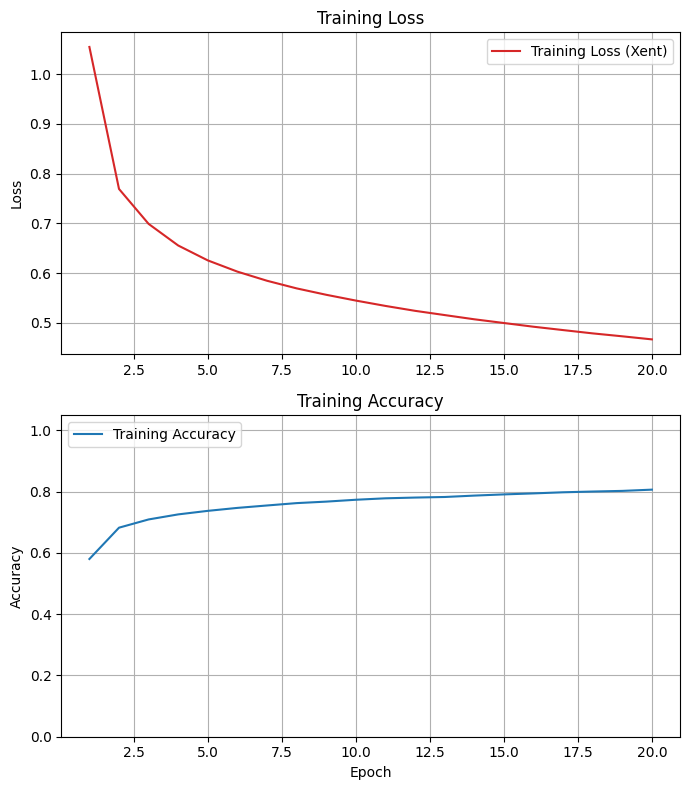

Final Training Loss:     0.4670
Final Training Accuracy: 0.8065
Final training accuracy at epoch 20 (lr=0.001): 0.8065

Training with learning_rate = 0.0005
Epoch 1/20
385/385 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.5271 - loss: 1.2649 - val_accuracy: 0.6207 - val_loss: 0.9182
Epoch 2/20
385/385 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.6541 - loss: 0.8415 - val_accuracy: 0.6766 - val_loss: 0.8027
Epoch 3/20
385/385 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.6912 - loss: 0.7647 - val_accuracy: 0.6987 - val_loss: 0.7485
Epoch 4/20
385/385 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.7064 - loss: 0.7196 - val_accuracy: 0.7101 - val_loss: 0.7096
Epoch 5/20
385/385 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.7164 - loss: 0.6868 - val_accuracy: 0.7228 - val_loss: 0.6804
Epoch 6/20
385/385 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.7264 - loss: 0.6614 - val_accuracy: 0.7312 - val_loss: 0.6585
Epoch 7/20
385/385 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.7341 - lo

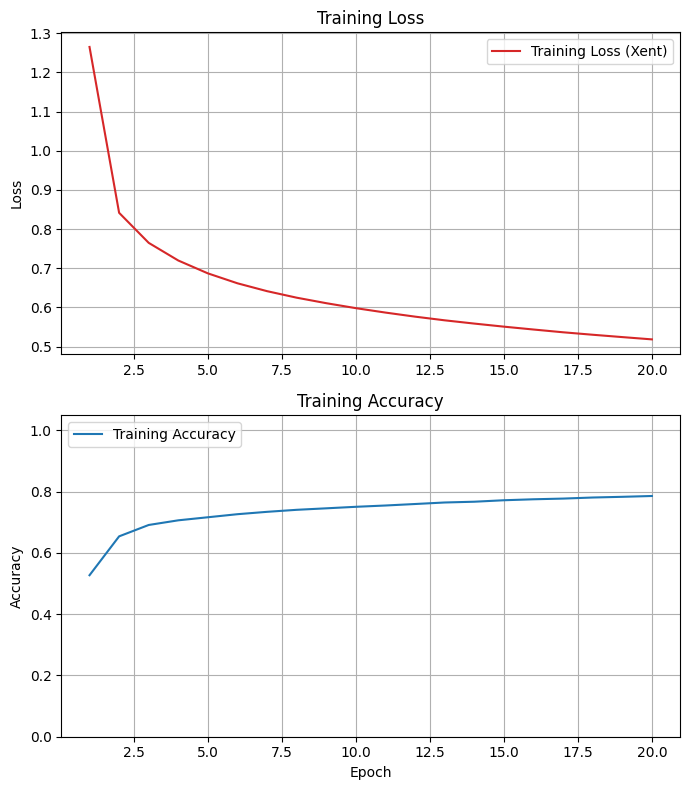

Final Training Loss:     0.5183
Final Training Accuracy: 0.7858
Final training accuracy at epoch 20 (lr=0.0005): 0.7858

Training with learning_rate = 0.0001
Epoch 1/20
385/385 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.3367 - loss: 1.7849 - val_accuracy: 0.4605 - val_loss: 1.5759
Epoch 2/20
385/385 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.5162 - loss: 1.4116 - val_accuracy: 0.5596 - val_loss: 1.2631
Epoch 3/20
385/385 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.5750 - loss: 1.1555 - val_accuracy: 0.5918 - val_loss: 1.0701
Epoch 4/20
385/385 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.5961 - loss: 1.0097 - val_accuracy: 0.6146 - val_loss: 0.9694
Epoch 5/20
385/385 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.6209 - loss: 0.9298 - val_accuracy: 0.6341 - val_loss: 0.9117
Epoch 6/20
385/385 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.6450 - loss: 0.8799 - val_accuracy: 0.6467 - val_loss: 0.8743
Epoch 7/20
385/385 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.6594 - l

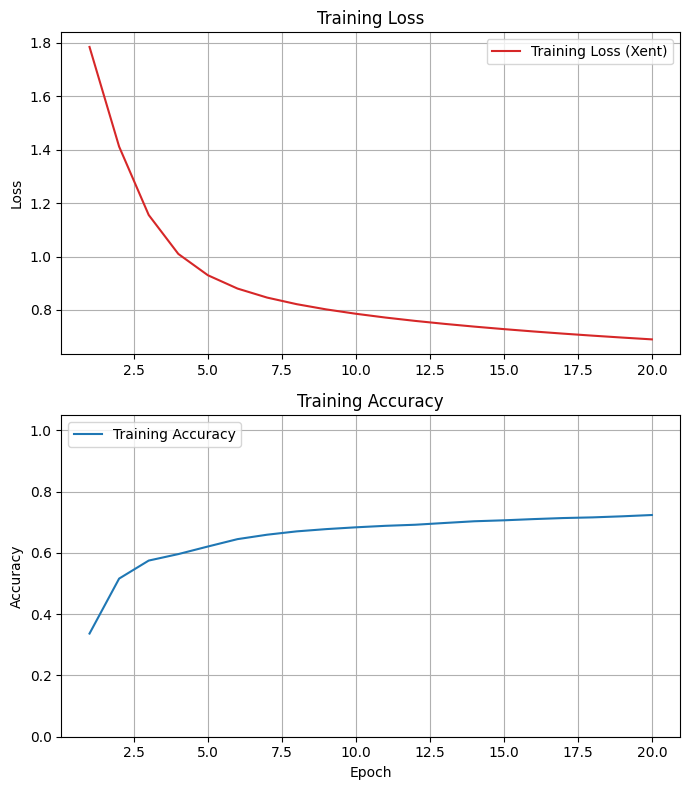

Final Training Loss:     0.6896
Final Training Accuracy: 0.7237
Final training accuracy at epoch 20 (lr=0.0001): 0.7237

Training with learning_rate = 5e-05
Epoch 1/20
385/385 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.3072 - loss: 1.8333 - val_accuracy: 0.4176 - val_loss: 1.6952
Epoch 2/20
385/385 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.4703 - loss: 1.5705 - val_accuracy: 0.5089 - val_loss: 1.4806
Epoch 3/20
385/385 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.5446 - loss: 1.3779 - val_accuracy: 0.5496 - val_loss: 1.3139
Epoch 4/20
385/385 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.5683 - loss: 1.2312 - val_accuracy: 0.5687 - val_loss: 1.1887
Epoch 5/20
385/385 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.5856 - loss: 1.1229 - val_accuracy: 0.5814 - val_loss: 1.0982
Epoch 6/20
385/385 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.5995 - loss: 1.0465 - val_accuracy: 0.5928 - val_loss: 1.0346
Epoch 7/20
385/385 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.6109 - lo

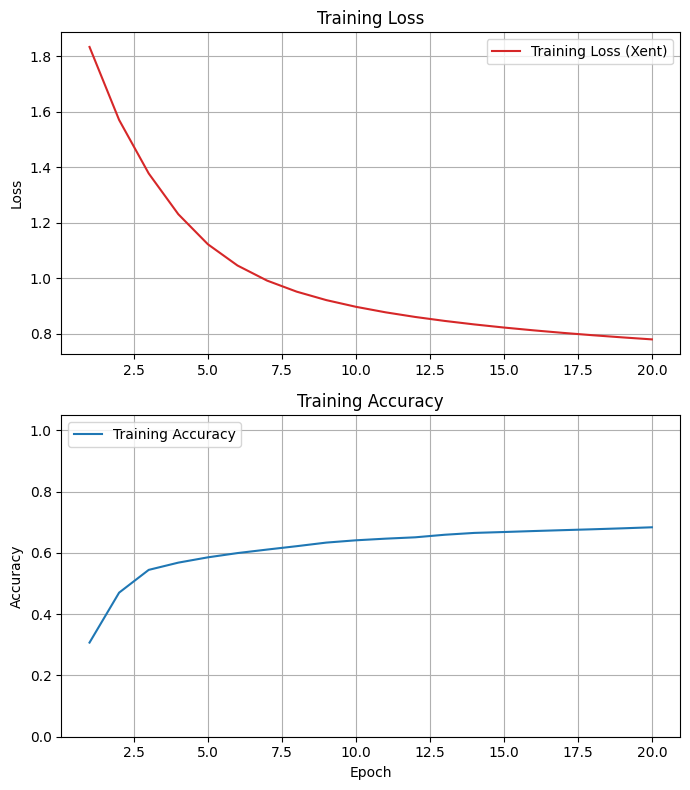

Final Training Loss:     0.7806
Final Training Accuracy: 0.6837
Final training accuracy at epoch 20 (lr=5e-05): 0.6837

Training with learning_rate = 1e-05
Epoch 1/20
385/385 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.1163 - loss: 2.0655 - val_accuracy: 0.1293 - val_loss: 2.0300
Epoch 2/20
385/385 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.1444 - loss: 1.9886 - val_accuracy: 0.1742 - val_loss: 1.9599
Epoch 3/20
385/385 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.1921 - loss: 1.9230 - val_accuracy: 0.2249 - val_loss: 1.8984
Epoch 4/20
385/385 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.2430 - loss: 1.8648 - val_accuracy: 0.2632 - val_loss: 1.8424
Epoch 5/20
385/385 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.2791 - loss: 1.8114 - val_accuracy: 0.3029 - val_loss: 1.7902
Epoch 6/20
385/385 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.3210 - loss: 1.7613 - val_accuracy: 0.3419 - val_loss: 1.7408
Epoch 7/20
385/385 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.3597 - los

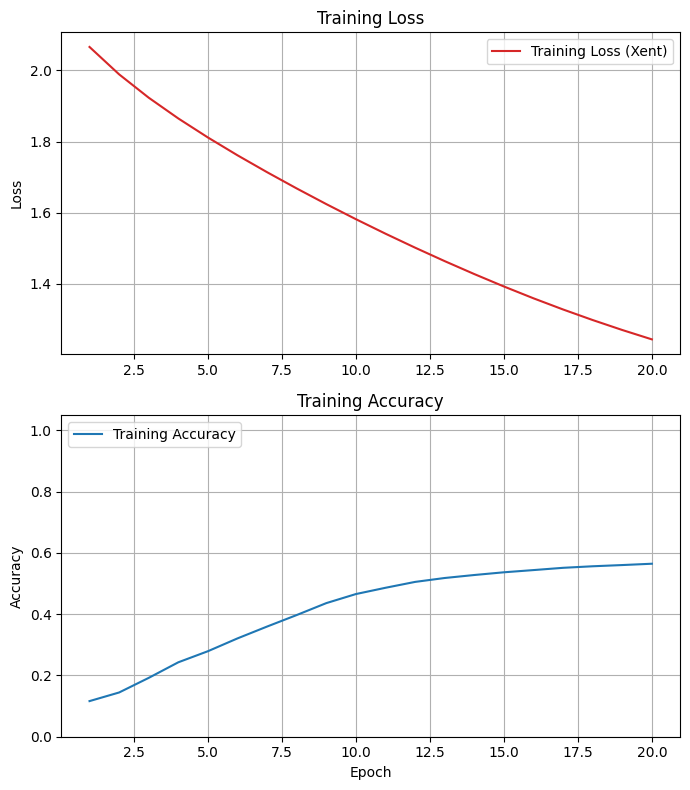

Final Training Loss:     1.2445
Final Training Accuracy: 0.5647
Final training accuracy at epoch 20 (lr=1e-05): 0.5647

Summary: Final Training Accuracy at Epoch 20
learning_rate=0.001   -> acc=0.8065
learning_rate=0.0005  -> acc=0.7858
learning_rate=0.0001  -> acc=0.7237
learning_rate=5e-05   -> acc=0.6837
learning_rate=1e-05   -> acc=0.5647

Best learning rate: 0.001
Best accuracy found (epoch 20): 0.8065


In [13]:
# Your code here
# Problem 3: Learning Rates
# Run 5 experiments with different Adam learning rates
# Here I’m keeping the model architecture and batch size fixed, and only varying the learning rate in Adam. 
# This isolates the effect of step size on optimization speed and stability. 
# I run five experiments, visualize each using plot_history, and then select the learning rate that achieves the highest training accuracy at epoch 20.

learning_rates = [1e-3, 5e-4, 1e-4, 5e-5, 1e-5]

histories_by_lr = {}
final_train_acc_by_lr = {}

n_features = X_train_scaled.shape[1]
n_classes = len(np.unique(y_train))

for lr in learning_rates:
    print("\n" + "="*70)
    print(f"Training with learning_rate = {lr}")
    print("="*70)

    # 1) Build a fresh model
    model_lr = Sequential([
        Input(shape=(n_features,)),
        Dense(64, activation="relu"),
        Dense(32, activation="relu"),
        Dense(n_classes, activation="softmax")
    ])

    # 2) Compile with current learning rate
    model_lr.compile(
        optimizer=Adam(learning_rate=lr),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )

    # 3) Train (same setup as baseline)
    history_lr = model_lr.fit(
        X_train_scaled,
        y_train,
        epochs=20,
        batch_size=32,          # keep batch size fixed
        validation_split=0.2,
        verbose=1
    )

    # 4) Plot training curves
    plot_history(history_lr)

    # 5) Record epoch-20 training accuracy
    final_acc = float(history_lr.history["accuracy"][-1])
    histories_by_lr[lr] = history_lr
    final_train_acc_by_lr[lr] = final_acc

    print(f"Final training accuracy at epoch 20 (lr={lr}): {final_acc:.4f}")

# Summary to identify the best learning rate
print("\n" + "="*70)
print("Summary: Final Training Accuracy at Epoch 20")
print("="*70)
for lr in learning_rates:
    print(f"learning_rate={lr:<7} -> acc={final_train_acc_by_lr[lr]:.4f}")

best_lr = max(final_train_acc_by_lr, key=final_train_acc_by_lr.get)
best_lr_acc = final_train_acc_by_lr[best_lr]

print("\nBest learning rate:", best_lr)
print("Best accuracy found (epoch 20):", f"{best_lr_acc:.4f}")


In [14]:
# Set a3a to the learning rate which produces the best (largest) accuracy at epoch 20

a3a = float(best_lr)

In [15]:
# Graded Answer
# DO NOT change this cell in any way          

print(f'a3a = {a3a:.4f}') 

a3a = 0.0010


In [16]:
# Set a3b to the accuracy found by the best learning rate

a3b = float(best_lr_acc)

In [17]:
# Graded Answer
# DO NOT change this cell in any way          

print(f'a3b = {a3b:.4f}') 

a3b = 0.8065


## Problem Four: Cosine Decay Learning Rate Scheduling

In this problem we'll gain some experience using the Cosine Decay learning rate scheduler with Adam. 

* Start with the code from **Problem One**.
* Define a `CosineDecay` learning rate scheduler (see `Week02_Coding.ipynb` for details)
* Use the scheduler with the Adam optimzier
* Run **five experiments** using the following values for `initial_learning_rate`:

        [1e-2, 5e-3, 1e-3,5e-4, 1e-4]

* Display your results using `plot_history` and answer the graded questions.

In [2]:
# Your code here
# In this problem I’m replacing the constant learning rate with a CosineDecay schedule while keeping the architecture, batch size, and optimizer (Adam) fixed. 
# I vary only the initial learning rate and evaluate how cosine decay affects optimization over 20 epochs. 
# I then select the initial learning rate that yields the best training accuracy at epoch 20.

# Problem 4: Cosine Decay Learning Rate Scheduling

initial_lrs = [1e-2, 5e-3, 1e-3, 5e-4, 1e-4]

histories_by_cd = {}
final_train_acc_by_cd = {}

n_features = X_train_scaled.shape[1]
n_classes = len(np.unique(y_train))

# Total decay steps: epochs * steps_per_epoch
steps_per_epoch = int(np.ceil(len(X_train_scaled) / 32))
decay_steps = steps_per_epoch * 20  # 20 epochs total

for init_lr in initial_lrs:
    print("\n" + "="*70)
    print(f"Training with CosineDecay initial_lr = {init_lr}")
    print("="*70)

    # 1) Define cosine decay scheduler
    lr_schedule = CosineDecay(
        initial_learning_rate=init_lr,
        decay_steps=decay_steps
    )

    # 2) Build fresh model
    model_cd = Sequential([
        Input(shape=(n_features,)),
        Dense(64, activation="relu"),
        Dense(32, activation="relu"),
        Dense(n_classes, activation="softmax")
    ])

    # 3) Compile with Adam + cosine decay
    model_cd.compile(
        optimizer=Adam(learning_rate=lr_schedule),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )

    # 4) Train
    history_cd = model_cd.fit(
        X_train_scaled,
        y_train,
        epochs=20,
        batch_size=32,
        validation_split=0.2,
        verbose=1
    )

    # 5) Plot results (professor-provided function)
    plot_history(history_cd)

    # 6) Record epoch-20 training accuracy
    final_acc = float(history_cd.history["accuracy"][-1])
    histories_by_cd[init_lr] = history_cd
    final_train_acc_by_cd[init_lr] = final_acc

    print(f"Final training accuracy at epoch 20 (init_lr={init_lr}): {final_acc:.4f}")

# Summary
print("\n" + "="*70)
print("Summary: Cosine Decay — Final Training Accuracy at Epoch 20")
print("="*70)
for lr in initial_lrs:
    print(f"initial_lr={lr:<7} -> acc={final_train_acc_by_cd[lr]:.4f}")

best_cd_lr = max(final_train_acc_by_cd, key=final_train_acc_by_cd.get)
best_cd_acc = final_train_acc_by_cd[best_cd_lr]

print("\nBest initial learning rate (CosineDecay):", best_cd_lr)
print("Best accuracy found (epoch 20):", f"{best_cd_acc:.4f}")

NameError: name 'X_train_scaled' is not defined

In [20]:
# Set a4a to the initial learning rate which produced the best accuracy

a4a = float(best_cd_lr)

In [21]:
# Graded Answer
# DO NOT change this cell in any way          

print(f'a4a = {a4a:.4f}') 

a4a = 0.0050


In [22]:
# Set a4b to the best accuracy found

a4b = float(best_cd_acc)

In [23]:
# Graded Answer
# DO NOT change this cell in any way          

print(f'a4b = {a4b:.4f}') 

a4b = 0.8676


## Problem Five: Find the best model and run on the test set

In this final problem, you must consider all the experiments you've done and pick the
set of training hyperparameters which gives you the best accuracy after 20 epochs. Do not change the model architecture. 

Your choices are:

- Which batch size?
- Cosine Decay or constant learning rate?
    - If Cosine Decay, which initial learning rate?
    - If not, which constant learning rate?

* Display your results using `plot_history`
* Run your best model on the test set
* Answer the graded questions.


**OPTIONAL: change the model architecture (but use only dense layers) and try other learning rate schedulers (exponential, step, etc.)**

In [23]:
# Your code here -- add as many cells as you need



In [24]:
# Set a5a to the best training accuracy found by your best model

a5a = 0.0             # Replace 0.0 with your answer

In [25]:
# Graded Answer
# DO NOT change this cell in any way          

print(f'a5a = {a5a:.4f}') 

a5a = 0.0000


In [26]:
# Set a5b to the test accuracy found by your best model

a5b = 0.0             # Replace 0.0 with your answer

In [27]:
# Graded Answer
# DO NOT change this cell in any way          

print(f'a5b = {a5b:.4f}') 

a5b = 0.0000


## Reflection Questions (ungraded)

1. We trained on a perfectly balanced \~3.3% subset.
   If we *increase the subset size* (still balanced), how would you expect (a) training time, (b) the best **batch size**, and (c) the best **learning rate** to change? Why?

2. **Batch size trade-offs.**
   With epochs fixed, why do smaller batches often generalize better on tabular data than large batches? What would you change if you *must* use a large batch?

3. **More epochs, same LR.**
    If you doubled the number of epochs (no other changes), what do you think would happen to train loss/acc and test acc? 

4. **Epochs vs. LR.**
   It is natural to think that there is an inverse relationship between the number of epochs and learning rate: if you move more slowly, it will take you longer to reach your goal. Does this seem true given what we have seen in the experiments with learning rate?

# Appendix:  Forest Cover Type (Covertype) — Dataset Overview

This dataset pairs **cartographic features** of 30×30 m land plots with the **dominant tree cover type**. Your task is to predict the cover type from terrain and soil indicators—an archetypal **multi-class classification** problem on tabular data.

**At a glance**

* **Samples:** 581,012 original; we’ll use a **balanced subset** (e.g., 2747 per class) for faster, fairer training.
* **Features (54 total):**

  * **10 continuous:** elevation, aspect, slope, distances to hydrology/roads/fire points, and hillshade at 9 AM/noon/3 PM.
  * **44 binary:** **4 Wilderness\_Area** flags and **40 Soil\_Type** one-hot indicators.
* **Target (7 classes):** Spruce/Fir, Lodgepole Pine, Ponderosa Pine, Cottonwood/Willow, Aspen, Douglas-fir, Krummholz.

**Why it’s useful here**

* Realistic, **tabular** data with mixed feature types.
* Clear demonstration of **scaling** (continuous features) vs. **binary indicators**.
* Originally **imbalanced**, which motivates mindful evaluation (we avoid this by using a balanced subset).


Shape: (19229, 55)

Class distribution:
 Cover_Type
3    0.142857
2    0.142857
6    0.142857
5    0.142857
4    0.142857
1    0.142857
0    0.142857
Name: proportion, dtype: float64


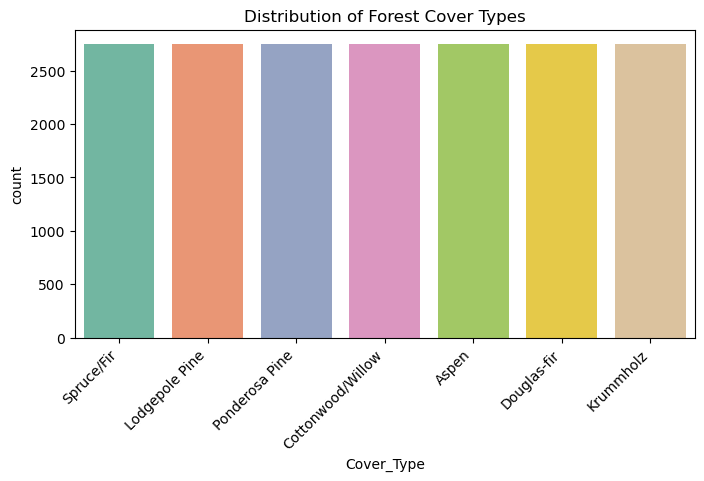

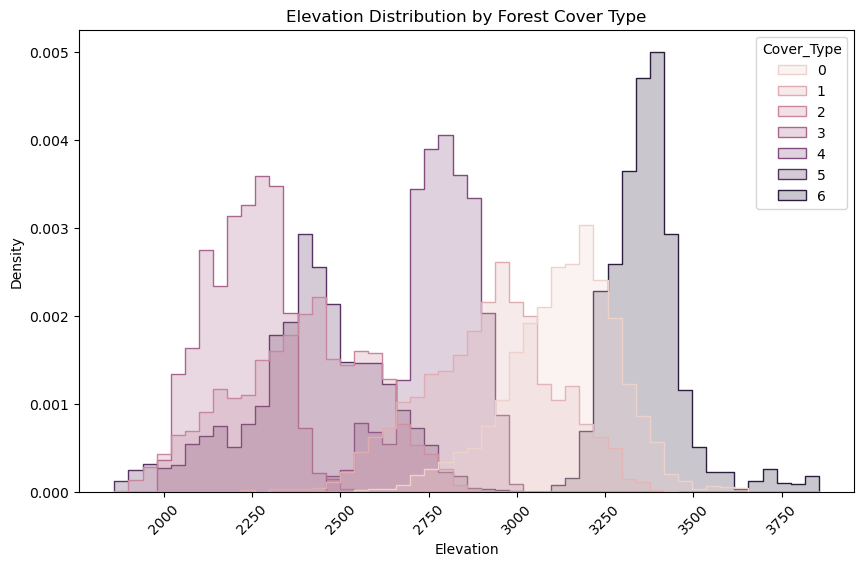

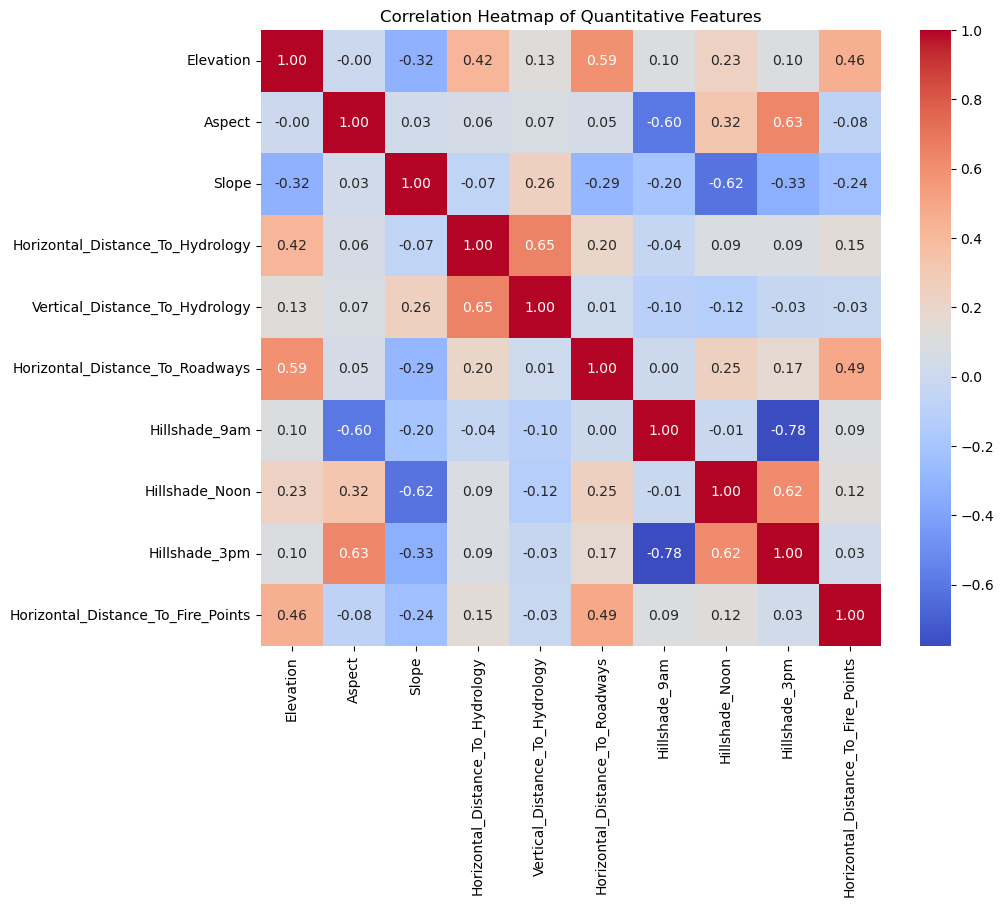

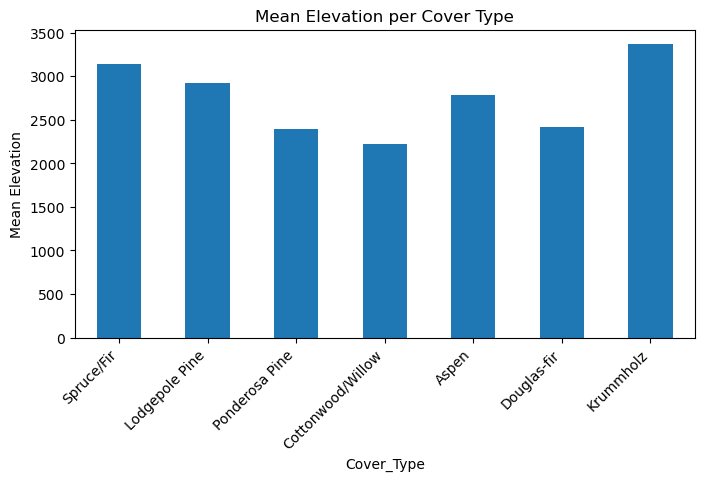

In [28]:
# Attach feature + class names
quant_features = [
    "Elevation", "Aspect", "Slope",
    "Horizontal_Distance_To_Hydrology",
    "Vertical_Distance_To_Hydrology",
    "Horizontal_Distance_To_Roadways",
    "Hillshade_9am", "Hillshade_Noon", "Hillshade_3pm",
    "Horizontal_Distance_To_Fire_Points"
]
wilderness_features = [f"Wilderness_Area{i}" for i in range(1, 5)]
soil_features = [f"Soil_Type{i}" for i in range(1, 41)]

feature_names = quant_features + wilderness_features + soil_features
class_names = [
    "Spruce/Fir", "Lodgepole Pine", "Ponderosa Pine",
    "Cottonwood/Willow", "Aspen", "Douglas-fir", "Krummholz"
]

# Create dataframe from your subset
df = pd.DataFrame(X_sub, columns=feature_names)
df["Cover_Type"] = y_sub

# 1. Basic info
print("Shape:", df.shape)
print("\nClass distribution:\n", df["Cover_Type"].value_counts(normalize=True))

# 2. Class distribution plot
plt.figure(figsize=(8,4))
sns.countplot(x="Cover_Type", hue="Cover_Type", data=df, palette="Set2", legend=False)
plt.xticks(ticks=range(7), labels=class_names, rotation=45, ha="right")
plt.title("Distribution of Forest Cover Types")
plt.show()

# 3. Elevation distribution by class
plt.figure(figsize=(10,6))
sns.histplot(data=df, x="Elevation", hue="Cover_Type",
             bins=50, element="step", stat="density", common_norm=False)
plt.xticks(rotation=45)
plt.title("Elevation Distribution by Forest Cover Type")
plt.show()

# 4. Correlation heatmap (quantitative features only)
plt.figure(figsize=(10,8))
corr = df[quant_features].corr()
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Correlation Heatmap of Quantitative Features")
plt.show()

# 5. Mean elevation per cover type
df.groupby("Cover_Type")["Elevation"].mean().plot(kind="bar", figsize=(8,4))
plt.xticks(ticks=range(7), labels=class_names, rotation=45, ha="right")
plt.ylabel("Mean Elevation")
plt.title("Mean Elevation per Cover Type")
plt.show()
